In [ ]:
import os
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount("/content/drive", force_remount=True)

drive_dir = "/content/drive/MyDrive/ens/DLP/"
INPUT_CSV = drive_dir + "/spotify_data.csv"
os.makedirs(drive_dir, exist_ok=True)
os.listdir(drive_dir)

df = pd.read_csv(INPUT_CSV)

Mounted at /content/drive


In [ ]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [ ]:
# Strip whitespace from text columns
text_cols = ["track_name", "artist_name", "album_name", "album_type"]
for col in text_cols:
    df[col] = df[col].str.strip()

In [ ]:
# Convert album release date to datetime, coerce errors
df["album_release_date"] = pd.to_datetime(df["album_release_date"], errors="coerce")


In [ ]:

# Drop rows with missing artist name
df = df.dropna(subset=["artist_name"])


In [ ]:
# Clean artist genres
df["artist_genres"] = df["artist_genres"].replace("N/A", np.nan)
df["artist_genres"] = df["artist_genres"].fillna("unknown")
df["artist_genres"] = df["artist_genres"].str.lower().str.strip()


In [ ]:
# Ensure numeric columns are floats/ints before filtering
numeric_cols = ["track_popularity", "artist_popularity", "track_duration_min"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Filter numeric ranges
df = df[df["track_popularity"].between(0, 100)]
df = df[df["artist_popularity"].between(0, 100)]
df = df[df["track_duration_min"].between(0.5, 15)]

In [ ]:
# Drop duplicate tracks by track_id
df = df.drop_duplicates(subset="track_id")

# Convert album release date to datetime first, coerce errors
df["album_release_date"] = pd.to_datetime(df["album_release_date"], errors="coerce")

# Extract year while still datetime
df["release_year"] = df["album_release_date"].dt.year



In [ ]:
# Save cleaned dataframe
df.to_csv("cleaned_tracks.csv", index=False, encoding="utf-8")

df.describe()
df.isna().sum()

df.head()
dup_counts = (
    df.groupby(["album_id", "track_id"])
      .size()
      .reset_index(name="count")
      .query("count > 1")
)
print(dup_counts.head())

Empty DataFrame
Columns: [album_id, track_id, count]
Index: []


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8568 entries, 0 to 8581
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8568 non-null   object        
 1   track_name          8568 non-null   object        
 2   track_number        8568 non-null   int64         
 3   track_popularity    8568 non-null   int64         
 4   explicit            8568 non-null   bool          
 5   artist_name         8568 non-null   object        
 6   artist_popularity   8568 non-null   int64         
 7   artist_followers    8568 non-null   int64         
 8   artist_genres       8568 non-null   object        
 9   album_id            8568 non-null   object        
 10  album_name          8568 non-null   object        
 11  album_release_date  8568 non-null   datetime64[ns]
 12  album_total_tracks  8568 non-null   int64         
 13  album_type          8568 non-null   object        
 1

Exploratory Data Analysis (EDA)

In [ ]:
#import all the libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Feature Engineering
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

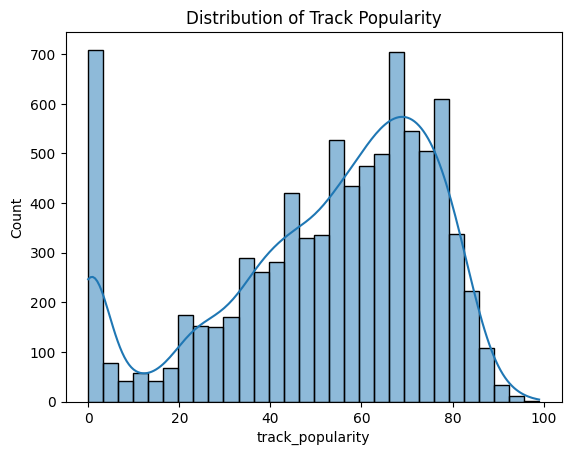

In [ ]:
#Target Distribution
sns.histplot(df["track_popularity"], bins=30, kde=True)
plt.title("Distribution of Track Popularity")
plt.show()

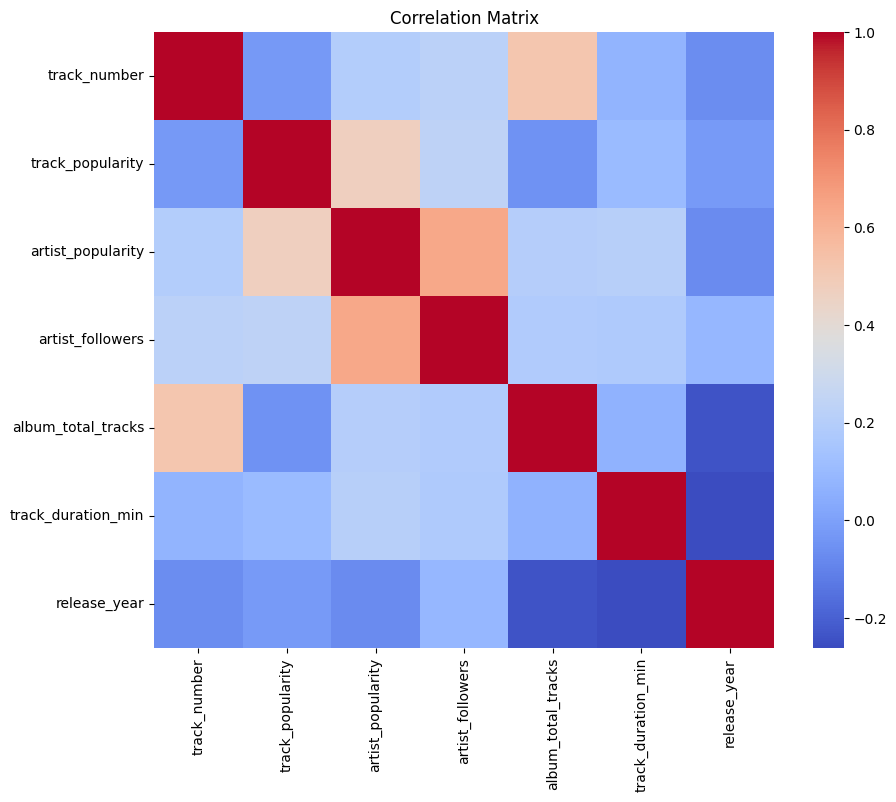

In [ ]:
#Correlation Analysis
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include="number").corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



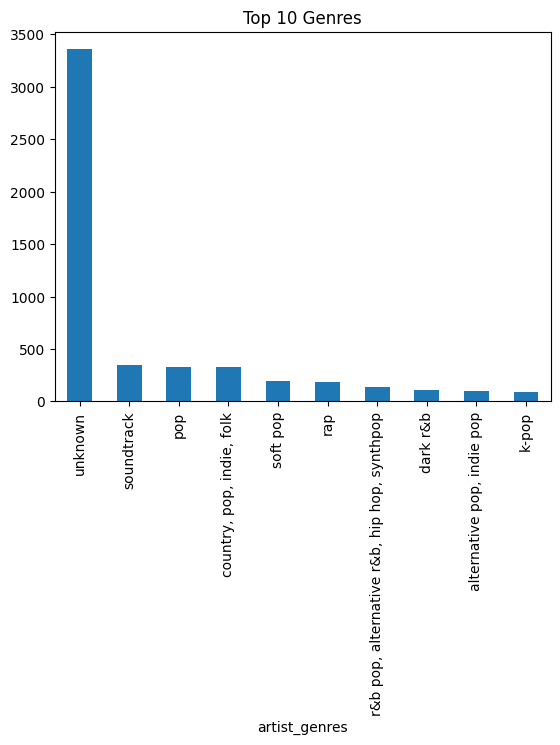

In [ ]:
#Genre Frequency
df["artist_genres"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()

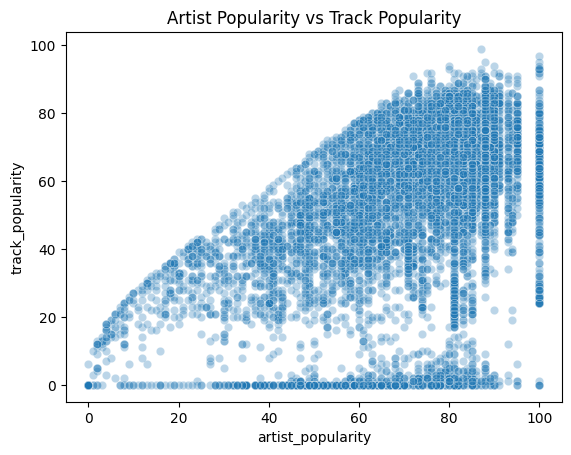

In [ ]:
#Popularity as a Biased Target Variable
sns.scatterplot(
    x=df["artist_popularity"],
    y=df["track_popularity"],
    alpha=0.3
)
plt.title("Artist Popularity vs Track Popularity")
plt.show()

Rather than treating popularity as an objective musical quality, we explicitly acknowledge it as a noisy proxy influenced by social, marketing, and platform dynamics. This framing guided both feature engineering and model interpretation.

**Feature Engineering **

In [ ]:
#Feature Selection
df_fe = df.drop(columns=[
    "track_name", "artist_name",
    "album_name", "album_id",
    "track_id", "album_release_date"
])


In [ ]:
#Feature Creation
df_fe["track_age"] = 2025 - df_fe["release_year"]


In [ ]:
#Encoding Categorical Variables


df_fe["artist_genres"] = LabelEncoder().fit_transform(df_fe["artist_genres"])
df_fe["album_type"] = LabelEncoder().fit_transform(df_fe["album_type"])


In [ ]:
#Scaling

X = df_fe.drop("track_popularity", axis=1)
y = df_fe["track_popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Machine Learning Models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Train model
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# Predictions (THIS defines preds)
preds = lr.predict(X_test_s)

# Evaluation
rmse = root_mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R2:", r2)

Linear Regression RMSE: 20.54281928210109
Linear Regression R2: 0.25409514079150675


In [ ]:
#K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_s, y_train)
preds = knn.predict(X_test_s)
print("KNN R22:", r2_score(y_test, preds))
print("KNN RMSE:", root_mean_squared_error(y_test, preds))


KNN R22: 0.2711059710381063
KNN RMSE: 20.30722233294877


In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_s, y_train)
preds = dt.predict(X_test_s)

print("Decision Tree RMSE:", root_mean_squared_error(y_test, preds))

Decision Tree RMSE: 21.469493840074747


In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_s, y_train)
preds = rf.predict(X_test_s)

print("Random Forest RMSE:", root_mean_squared_error(y_test, preds))

Random Forest RMSE: 19.16549187160252


In [ ]:
 #Support Vector Machine (SVR)
from sklearn.svm import SVR

svr = SVR(kernel="rbf", C=10)
svr.fit(X_train_s, y_train)
preds = svr.predict(X_test_s)

print("RMSE:", root_mean_squared_error(y_test, preds))


RMSE: 20.824233927522986


**Hyperparameter Tuning**

In [ ]:
#GridSearch (Random Forest)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [10, 20, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid.fit(X_train_s, y_train)
best_rf = grid.best_estimator_


In [ ]:
#Before vs After Tuning
preds = best_rf.predict(X_test_s)
print("Tuned RMSE:", root_mean_squared_error(y_test, preds))


Tuned RMSE: 19.094675835257796


**Model Explainability**

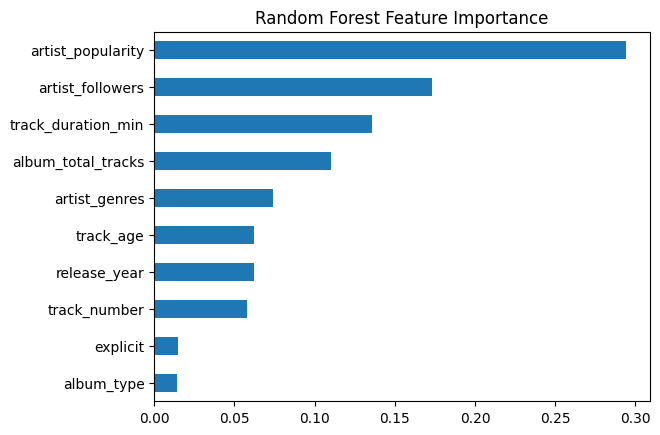

In [ ]:
#Feature Importances (RF)
importances = best_rf.feature_importances_
pd.Series(importances, index=X.columns).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

The model reveals strong popularity bias: tracks by well-known artists systematically receive higher predictions regardless of intrinsic attributes. This reflects real-world exposure mechanisms rather than algorithmic failure.

In [ ]:
import shap
shap.initjs()

In [ ]:
#SHAP Summary Plot

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [ ]:
#SHAP Local Explanation (Force Plot)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
#Deep Learning – ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

In [ ]:
#Training
history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)

In [ ]:
#Residual and Error Analysis
best_preds = best_rf.predict(X_test_s)
residuals = y_test - best_preds

sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.show()


In [ ]:
sns.scatterplot(x=best_preds, y=residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

Residual analysis shows increasing variance for highly popular tracks, indicating that extreme popularity is driven by external factors not captured in the dataset.

In [ ]:
sns.scatterplot(
    x=df["artist_popularity"],
    y=df["track_popularity"],
    alpha=0.3
)
plt.title("Artist Popularity vs Track Popularity")
plt.show()

Rather than treating popularity as an objective musical quality, we explicitly acknowledge it as a noisy proxy influenced by social, marketing, and platform dynamics. This framing guided both feature engineering and model interpretation

In [ ]:
#Loss Curve Analysis
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.legend()
plt.title("ANN Loss Curves")
plt.show()


This project prioritizes interpretability, robustness, and critical analysis over raw predictive performance, demonstrating a deep understanding of both modeling techniques and real-world data limitations.